**Author**: Felipe Matheus  
**Pipeline**: Uncertainty-aware Model-Based Controller (MBC) — Annealing

Probabilistic counterpart of the deterministic `mbc_annealing_ngsz.ipynb`. Same
shape — fix the material state, sweep a dense (temperature, time) grid, predict
every cell, filter by setpoints, rank by cost, export — but every prediction is
now a **calibrated Gaussian predictive distribution** instead of a point, and the
hard setpoint filter `pred >= min` becomes the chance constraint
**Pr(Y >= y_target) >= 1 - delta** (copper_digital_twin_v4 §2.1).

What changed vs. the deterministic MBC:
- **Models**: AutoGluon artifact down_bundles (`artifacts.pkl` + `model_a/` + `model_b/`)
  from the annealing notebooks — NOT H2O + scalers. AutoGluon preprocesses
  internally, so there are no manual scalers here.
- **Prediction**: `mu, sigma_total` (epistemic + aleatoric, recalibrated, truncated)
  per cell, via `MBCInference` → `Modeling.predict_with_uncertainty`.
- **Feasibility**: `Pr(Y >= setpoint)` under the truncated law, gated at `1 - delta`.
- **Ranking**: still cost-based, plus optional risk-aware LCB (`mu - kappa*sigma`).

# 1. Setup

In [1]:
import os
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.modeling.Modeling import Modeling
from src.modeling.MBCInference import MBCInference
from src.metrics.ProbabilisticEvaluation import ProbabilisticEvaluation
from src.DataLoader import LoaderHelper
from config.Variables import Variables

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

%load_ext autoreload
%autoreload 2

modl = Modeling()
load = LoaderHelper()
varv = Variables()
mbc = MBCInference(modl, load)
pev = ProbabilisticEvaluation()

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Configuration

`material_properties` are the FIXED features of the current state (everything the
surrogates need except temperature/time, which are swept). `operational_limits`
and `step` define the grid; `min_setpoints` the targets; `delta` the risk knob.

In production these come from `config/config_script_annealing.yaml`; here they are
inline for clarity. Note the bundle dirs point at the run folders produced by
Section 10 of the annealing notebooks (or any `<run_dir>` from ExperimentRunner).

In [14]:
# ---- Surrogate artifact down_bundles (each: artifacts.pkl + model_a/ + model_b/) ----
# ---- TAG folders (best run auto-picked by RMSE, no hard-coded hash) ----
IACS_TAG_DIR = os.path.join(varv.PATHS.models, "annealing_iacs",
                            "experiments", "annealing-v1-best-quality")
UTS_TAG_DIR  = os.path.join(varv.PATHS.models, "annealing_uts",
                            "experiments", "annealing-uts-v1-best_quality")

down_bundles = mbc.load_surrogates_best(
    {"iacs": IACS_TAG_DIR, "uts": UTS_TAG_DIR}, metric="rmse",
)

# ---- Fixed material state (features other than temperature/time) ----
# Must contain every non-grid feature each surrogate needs:
#   IACS needs: purity, iacs        UTS needs: purity, initial_diameter, tensile_strength
MATERIAL_PROPERTIES = {
    "purity": 99.95,
    "iacs": 98.47,
    "initial_diameter": 1.2,
    "tensile_strength": 250.0,
}

# ---- Grid (inclusive of upper bound, like the deterministic build_param_grid) ----
OPERATIONAL_LIMITS = {
    "temperature": [523, 723],   # Kelvin
    "time": [30, 120],           # minutes
}
STEP = {"temperature": 10, "time": 5}

# ---- Probabilistic acceptance ----
MIN_SETPOINTS = {"iacs": 99.5, "tensile_strength": 210.0}   # short_name -> minimum
DELTA = 0.10                                    # keep cells with Pr >= 1 - delta
KAPPA = 1.645                                   # one-sided 95% LCB for risk ranking

# ---- Selection criteria (mirror the deterministic labels) ----
SELECTION_SPEC_LOW = {
    "lowest_time": "time",
    "lowest_temperature": "temperature",
    "lowest_cost": "cost",
    "lowest_cost_phys": "cost_phys",
}
SELECTION_SPEC_HIGH = {
    "safest_iacs": "pr_success_iacs",
    "safest_combined": "pr_success_all",
}

2026-06-25 23:27:14,496 | INFO | src.modeling.MBCInference | Resolved best bundle by rmse: annealing-v1-best-quality__time_limit_a=1500__num_bag_folds_a=20__weight_on_essay_rows=1.0__d91e7f29
2026-06-25 23:27:14,498 | INFO | src.modeling.MBCInference | Resolved best bundle by rmse: annealing-uts-v1-best_quality__time_limit_a=900__num_bag_folds_a=10__df848c54
2026-06-25 23:27:14,864 | INFO | src.modeling.MBCInference | Loaded surrogate 'iacs' (features=['purity', 'iacs', 'temperature', 'time']) from ..\..\models\annealing_iacs\experiments\annealing-v1-best-quality\annealing-v1-best-quality__time_limit_a=1500__num_bag_folds_a=20__weight_on_essay_rows=1.0__d91e7f29
2026-06-25 23:27:15,184 | INFO | src.modeling.MBCInference | Loaded surrogate 'tensile_strength' (features=['purity', 'initial_diameter', 'tensile_strength', 'temperature', 'time']) from ..\..\models\annealing_uts\experiments\annealing-uts-v1-best_quality\annealing-uts-v1-best_quality__time_limit_a=900__num_bag_folds_a=10__df84

# 3. Load surrogates

In [15]:
# down_bundles = mbc.load_surrogates(BUNDLE_DIRS)
for key, b in down_bundles.items():
    art = b.artifacts
    print(f"[{key}] target={b.target} | features={b.features}")
    print(f"      recalibration_c={art['recalibration_c']:.4f} | "
          f"y_min={art.get('y_min')} y_max={art.get('y_max')}")

[iacs] target=iacs_final | features=['purity', 'iacs', 'temperature', 'time']
      recalibration_c=1.0902 | y_min=None y_max=None
[uts] target=tensile_strength_final | features=['purity', 'initial_diameter', 'tensile_strength', 'temperature', 'time']
      recalibration_c=0.8647 | y_min=0.0 y_max=None


# 4. Build the (temperature, time) grid

The fixed material state is broadcast across every grid cell. Each surrogate will
later pick only the columns it needs, so IACS (4 features) and UTS (5 features)
share the same frame.

In [16]:
param_grid = mbc.build_param_grid(OPERATIONAL_LIMITS, STEP)
df_grid = mbc.build_state_grid_df(MATERIAL_PROPERTIES, param_grid)

print(f"Grid: {len(param_grid['temperature'])} temperatures x "
      f"{len(param_grid['time'])} times = {len(df_grid)} cells")
df_grid.head()

Grid: 21 temperatures x 19 times = 399 cells


,purity,iacs,initial_diameter,tensile_strength,temperature,time
0,99.95,98.47,1.2,250.0,523,30
1,99.95,98.47,1.2,250.0,523,35
2,99.95,98.47,1.2,250.0,523,40
3,99.95,98.47,1.2,250.0,523,45
4,99.95,98.47,1.2,250.0,523,50


# 5. Predict — full predictive distribution per cell

`predict_all` runs each surrogate's `predict_with_uncertainty` (epistemic +
aleatoric variance, OOD inflation, scalar recalibration, physical truncation) and
merges the distribution columns. For surrogate `s` you get `s_mu`, `s_sigma`,
`s_sigma2_epist`, `s_sigma2_aleat`, `s_ood_multiplier` (+ truncation columns when
the surrogate has a finite physical bound, e.g. IACS at 105).

In [17]:
df_pred = mbc.predict_all(down_bundles, df_grid, ood_gamma=1.0)

dist_cols = [c for c in df_pred.columns
             if any(c.startswith(p) for p in ("iacs_", "uts_"))]
df_pred[["temperature", "time"] + dist_cols].head()

,temperature,time,iacs_mu,iacs_sigma,iacs_sigma2_epist,iacs_sigma2_aleat,iacs_ood_multiplier
0,523,30,100.122591,1.305880,0.023167,1.411706,1.0
1,523,35,99.355366,1.383696,0.199268,1.411706,1.0
2,523,40,99.350637,1.383696,0.199269,1.411706,1.0
3,523,45,99.345847,1.383721,0.199327,1.411706,1.0
4,523,50,99.463805,1.468305,0.402303,1.411706,1.0


# 6. Probabilistic feasibility — Pr(Y >= setpoint)

The deterministic controller kept cells where `pred >= min`. Here we compute, under
the calibrated **truncated** predictive law, the probability each target clears its
setpoint, then gate at `Pr >= 1 - delta`. `pr_success_all` multiplies the per-target
probabilities (independence assumption — conservative and transparent).

In [18]:
# physical bounds per surrogate, so probabilities use the truncated law
surrogate_bounds = {
    key: (b.artifacts.get("y_min"), b.artifacts.get("y_max"))
    for key, b in down_bundles.items()
}

df_prob = pev.add_success_probabilities(
    df_pred, MIN_SETPOINTS, surrogate_bounds=surrogate_bounds, modl=modl,
)
df_prob[["temperature", "time", "iacs_mu", "iacs_sigma", "pr_success_iacs",
         "tensile_strength_mu", "tensile_strength_sigma", "pr_success_tensile_strength", "pr_success_all"]].head(10)

,temperature,time,iacs_mu,iacs_sigma,pr_success_iacs,tensile_strength_mu,tensile_strength_sigma,pr_success_tensile_strength,pr_success_all
0,523,30,100.122591,1.305880,0.683233,232.148544,18.802371,0.880595,0.601652
1,523,35,99.355366,1.383696,0.458375,231.148034,19.318132,0.863181,0.395661
2,523,40,99.350637,1.383696,0.457020,231.124011,19.330748,0.862752,0.394295
3,523,45,99.345847,1.383721,0.455648,231.100029,19.343348,0.862323,0.392916
4,523,50,99.463805,1.468305,0.490167,232.516513,20.206089,0.867434,0.425187
5,523,55,99.459653,1.468945,0.489044,232.492959,20.219347,0.867027,0.424014
6,523,60,99.238353,1.555261,0.433200,231.218039,21.453522,0.838674,0.363313
7,523,65,98.231932,2.102752,0.273237,229.381404,22.956513,0.800740,0.218792
8,523,70,98.208438,2.114715,0.270683,229.362960,22.971588,0.800360,0.216644
9,523,75,98.184306,2.126851,0.268086,229.344789,22.986683,0.799984,0.214465


In [19]:
df_pred

,purity,iacs,initial_diameter,tensile_strength,temperature,time,iacs_mu,iacs_sigma,iacs_sigma2_epist,iacs_sigma2_aleat,iacs_ood_multiplier,tensile_strength_mu,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max
0,99.95,98.47,1.2,250.0,523,30,100.122591,1.305880,0.023167,1.411706,1.0,232.148544,18.802371,108.445853,364.319336,1.0,232.148544,18.802371,0.0
1,99.95,98.47,1.2,250.0,523,35,99.355366,1.383696,0.199268,1.411706,1.0,231.148034,19.318132,134.738086,364.319336,1.0,231.148034,19.318132,0.0
2,99.95,98.47,1.2,250.0,523,40,99.350637,1.383696,0.199269,1.411706,1.0,231.124011,19.330748,135.390129,364.319336,1.0,231.124011,19.330748,0.0
3,99.95,98.47,1.2,250.0,523,45,99.345847,1.383721,0.199327,1.411706,1.0,231.100029,19.343348,136.041779,364.319336,1.0,231.100029,19.343348,0.0
4,99.95,98.47,1.2,250.0,523,50,99.463805,1.468305,0.402303,1.411706,1.0,232.516513,20.206089,181.670803,364.319336,1.0,232.516513,20.206089,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,99.95,98.47,1.2,250.0,723,100,99.174816,1.894453,1.608072,1.411706,1.0,177.033390,20.261984,184.695644,364.319336,1.0,177.033390,20.261984,0.0
395,99.95,98.47,1.2,250.0,723,105,99.139278,1.907681,1.650390,1.411706,1.0,177.040804,20.269413,185.098309,364.319336,1.0,177.040804,20.269413,0.0
396,99.95,98.47,1.2,250.0,723,110,99.103147,1.922227,1.697263,1.411706,1.0,177.529549,20.248125,183.944848,364.319336,1.0,177.529549,20.248125,0.0
397,99.95,98.47,1.2,250.0,723,115,99.065293,1.937658,1.747379,1.411706,1.0,177.537490,20.255312,184.334159,364.319336,1.0,177.537490,20.255312,0.0


In [20]:
df_feasible = pev.apply_probabilistic_setpoints(df_prob, delta=DELTA)
print(f"Feasible cells at delta={DELTA} (Pr >= {1-DELTA:.2f}): "
      f"{len(df_feasible)} / {len(df_prob)}")
df_feasible.head()

2026-06-25 23:27:33,109 | INFO | src.metrics.ProbabilisticEvaluation | Probabilistic setpoints (delta=0.10 -> Pr>=0.90): kept 0 / 399 cells.


Feasible cells at delta=0.1 (Pr >= 0.90): 0 / 399


,purity,iacs,initial_diameter,tensile_strength,temperature,time,iacs_mu,iacs_sigma,iacs_sigma2_epist,iacs_sigma2_aleat,...,tensile_strength_sigma,tensile_strength_sigma2_epist,tensile_strength_sigma2_aleat,tensile_strength_ood_multiplier,tensile_strength_mu_trunc,tensile_strength_sigma_trunc,tensile_strength_p_above_max,pr_success_iacs,pr_success_tensile_strength,pr_success_all


## 6.1 Visualise the feasibility map

Heatmap of `pr_success_all` over the grid: where on the (T, t) plane is the route
safe? The deterministic controller could only show a hard yes/no boundary; here you
see the full probability gradient.

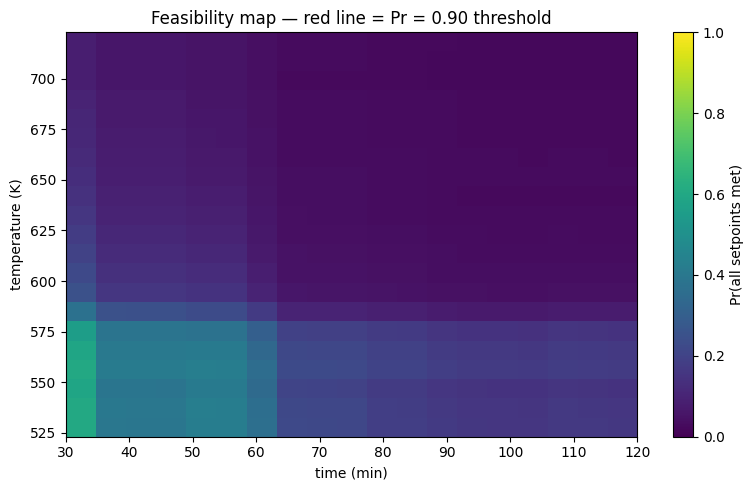

In [21]:
pivot = df_prob.pivot(index="temperature", columns="time",
                      values="pr_success_all")
plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto", origin="lower",
           extent=[pivot.columns.min(), pivot.columns.max(),
                   pivot.index.min(), pivot.index.max()],
           cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Pr(all setpoints met)")
plt.contour(pivot.columns, pivot.index, pivot.values,
            levels=[1 - DELTA], colors="red", linewidths=2)
plt.xlabel("time (min)"); plt.ylabel("temperature (K)")
plt.title(f"Feasibility map — red line = Pr = {1-DELTA:.2f} threshold")
plt.tight_layout(); plt.show()

# 7. Cost functions + risk-aware value

Operational cost (lower T, lower t = cheaper) and a physics budget proxy (T*t),
both normalised. Plus a one-sided 95% lower confidence bound on IACS so that, among
equally-cheap cells, the controller can prefer the one whose guarantee is robust.

In [22]:
df_cost = pev.add_cost_function(
    pev.add_cost_function_physics(df_feasible),
    operational_limits=OPERATIONAL_LIMITS,
)
df_cost = pev.add_risk_adjusted_value(df_cost, "iacs", kappa=KAPPA)
df_cost = pev.add_risk_adjusted_value(df_cost, "uts", kappa=KAPPA)

df_cost[["temperature", "time", "cost", "cost_phys",
         "iacs_mu", "iacs_lcb", "pr_success_all"]].sort_values("cost").head()

ValueError: zero-size array to reduction operation maximum which has no identity

# 8. Select operating points

In [ ]:
selected_low = pev.select_lowest_by_features(df_cost, SELECTION_SPEC_LOW)
selected_high = pev.select_highest_by_features(df_cost, SELECTION_SPEC_HIGH)
selected = {**selected_low, **selected_high}

for label, sub in selected.items():
    if len(sub):
        r = sub.iloc[0]
        print(f"{label:20s} -> T={r['temperature']:.0f}K t={r['time']:.0f}min "
              f"| iacs_mu={r['iacs_mu']:.2f} (+/-{r['iacs_sigma']:.2f}) "
              f"| Pr_all={r['pr_success_all']:.3f}")

In [ ]:
# The "best for production" pick: cheapest cell that is also safe.
# (df_cost already passed the delta gate, so any of these is feasible.)
selected["lowest_cost"]

# 9. Inspect specific (T, t) pairs

Same targeted inspection the deterministic notebook offered, now with full
distribution + probability columns.

In [ ]:
df_pairs = pev.filter_by_temperature_time_pairs(
    df_prob, temperatures=[573, 623, 673], times=[30, 60, 90],
)
df_pairs["temperature_C"] = df_pairs["temperature"] - 273
df_pairs[["temperature_C", "time", "iacs_mu", "iacs_sigma", "pr_success_iacs",
          "uts_mu", "uts_sigma", "pr_success_uts", "pr_success_all"]]

# 10. Export selections

In [ ]:
from src.mbc.ProbabilisticEvaluation import ProbabilisticEvaluation
from pathlib import Path

IDENTIFIER = "uncertainty_aware_pilot"
output_dir = Path(varv.PATHS.data_enriched) / "mbc_annealing_uncertainty"
output_dir.mkdir(parents=True, exist_ok=True)

# one tidy CSV: every selected operating point, labelled
rows = []
for label, sub in selected.items():
    if len(sub):
        r = sub.iloc[0].copy()
        r["selection"] = label
        rows.append(r)
export_df = pd.DataFrame(rows)
export_cols = (["selection", "temperature", "time"]
               + [c for c in export_df.columns
                  if c.endswith(("_mu", "_sigma")) or c.startswith("pr_success")
                  or c in ("cost", "cost_phys", "iacs_lcb", "uts_lcb")])
export_df = export_df[[c for c in export_cols if c in export_df.columns]]
export_df["temperature_C"] = export_df["temperature"] - 273

out_path = output_dir / f"mbc_ann_unc_{IDENTIFIER}.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved {len(export_df)} selections to {out_path}")
export_df